# Module 3 Homework - Seaborn
Using a dataset about Pokemon combat statistic, we will practice data visualization using the seaborn library.  
<img src="https://cdn.arstechnica.net/wp-content/uploads/2020/07/pokemon-go-masks-800x450.jpg">

In this notebook, we will plot the relationships between different observations of the combat statistics of Pokémon. You will need to import a few packages, including `pandas`, `matplotlib.pyplot`, and `seaborn`. The data is stored in a csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv

Here are the descriptions of this dataset:
- `#` - Pokedex entry number of the Pokemon
- `Name` - name of the Pokemon
- `Type 1` - each Pokemon has a type, this determines weakness/resistance to attacks [referred to as the primary type]
- `Type 2` - some Pokemon are dual type and have 2 [referred to as the secondary type]
- `Total` - sum of all stats that come after this, a general guide to how strong a Pokemon is
- `HP` - hit points, or health, defines how much damage a Pokemon can withstand before fainting
- `Attack` - the base modifier for normal attacks
- `Defense` - the base damage resistance against normal attacks
- `Sp. Atk` - special attack, the base modifier for special attacks
- `Sp. Def` - the base damage resistance against special attacks
- `Speed` - determines which Pokemon attacks first each round
- `Generation` - refers to which grouping/game series the Pokemon was released in
- `Legendary` - a boolean that identifies whether the Pokemon is legendary

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

fp = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv"

## Q1: Plot the relationship between Attack and Defense
Create a relationship plot using seaborn's `relplot` function. Plot `Attack` on the x-axis and `Defense` on the y-axis. Use `hue` to display the `HP` (hit point) for each datapoint. You can choose your favorite palette. Include a meaninful title in the plot. After creating the plot, insert a markdown cell :immediately following the plot to describe the relationship between Attack and Defense in this dataset.

### From the plot, I observed....
Results: There is a positive correlation between `Attack` and `Defense`. The hit-points (`HP`) is higher for Pokemons with higher `Attack` and `Defense` values.

<Figure size 1000x800 with 0 Axes>

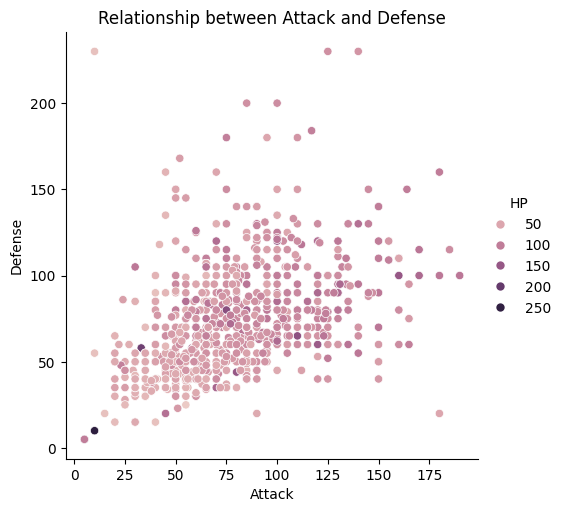

In [3]:
# Your code here . . .
plt.figure(figsize=(10, 8))
sns.relplot(x="Attack", y="Defense", hue="HP", data=pd.read_csv(fp))
plt.title("Relationship between Attack and Defense")
plt.show()

Observation: In the graph we can see that in most cases characters with higher attack have higher health but that is not always the case. There are characters with 250 health that have realtively low attack and defense. Also a lot of characters between range of attack 25-75 have relatively same hp 50-100.

## Q2: Plot the relationship between Attack and Total using a hexbin plot
Create a hexbin plot using seaborn's `joinplot` function. Plot `Attack` on the x-axis and `Total` on the y-axis. You can choose the gridsize. Include a title for the plot "Attack vs total for all Pokemon". After generating the plot, insert a markdown cell to answer this question: The hexbin plot displays the relationship between `Attack` and `Total`, what else does this plot show?

<Figure size 1000x800 with 0 Axes>

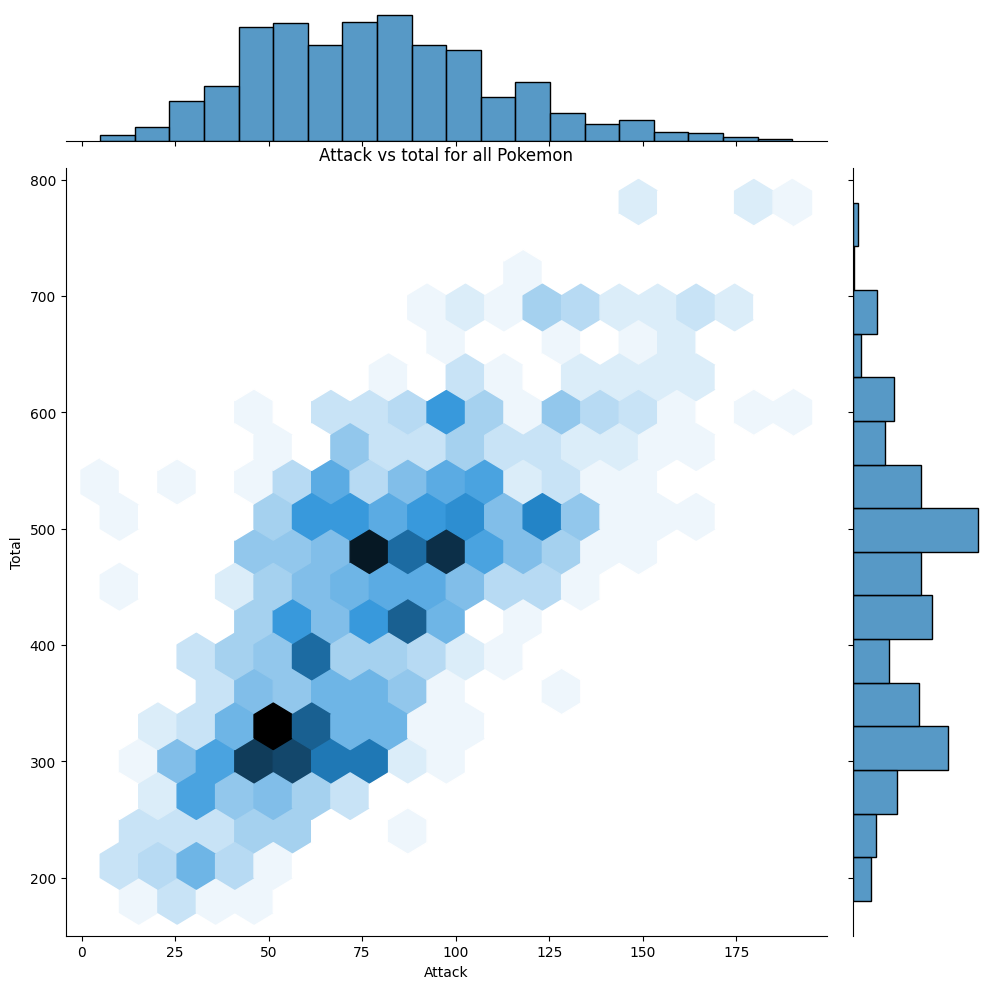

In [16]:
# Your code here . . .
df = pd.read_csv(fp)
plt.figure(figsize=(10, 8))
sns.jointplot(x="Attack", y="Total", data=df, kind="hex", height=10)
plt.title("Attack vs total for all Pokemon")
plt.show()

Observation: Besides the relationship between Attack and Total, the plot also shows strong density of observation where darker hexagons represent areas where more Pokemon are concentrated. This shows which Attack and Total combinations are most common.

From the plot, I observed....

## Q3: Create two categorical plots for Pokemon types. `Type 1` and `Type 2` .
For each plot, the unique values of `Type 1` or `Type 2` should be plotted along the y-axis, and the counts of Pokemon should be on the x-axis. Use the color red for the `Type 1` plot and blue for the `Type 2` plot. After the two plots are displayed, insert a markdown cell to write your findings: Which are the most common `Type 1` and `Type 2` Pokemons, and which are the most rare ones?

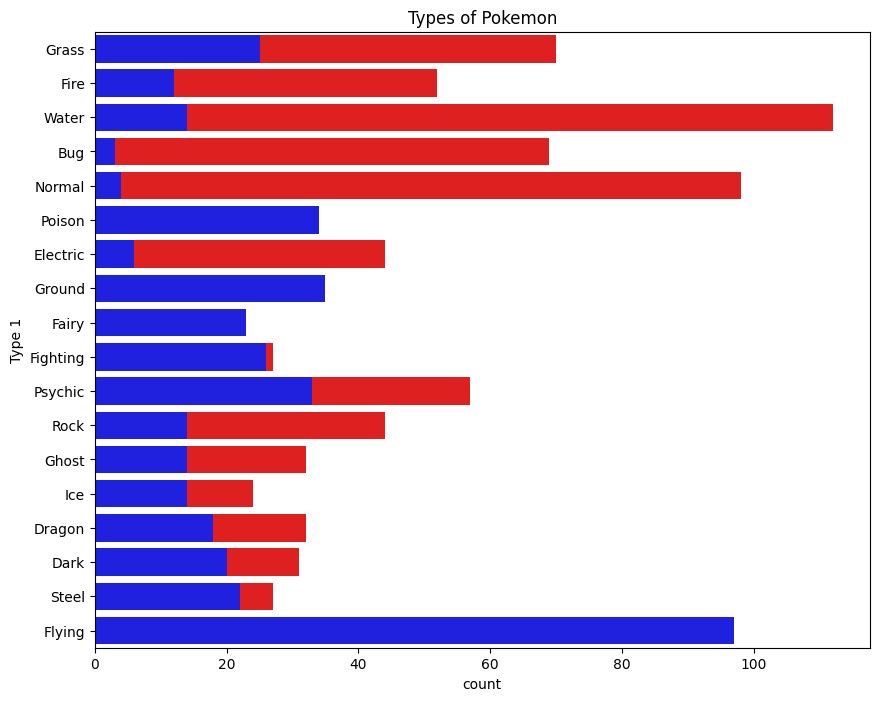

In [18]:
# Your code here . . .
plt.figure(figsize=(10, 8))
sns.countplot(y="Type 1", data=df, color="red")
sns.countplot(y="Type 2", data=df, color="blue")
plt.title("Types of Pokemon")
plt.show()

Observation: The most common Type 1 Pokemons are Water and Normal Pokemons. (Grass is also popular one).

The most common Type 2 Pokemons are Flying, Ground and Poison, but Psychic can also be up there.

The most rare Type 1 Pokemons are definetly Fighting, Ice, and Steel.

The most rare Type 2 Pokemons are definetly Bug, Normal and Electric.

## Q4-6: Your own question
Come up with three more questions to further explore the pokemon dataset.

## Q4: How are Pokemon Stats distributeed overall?

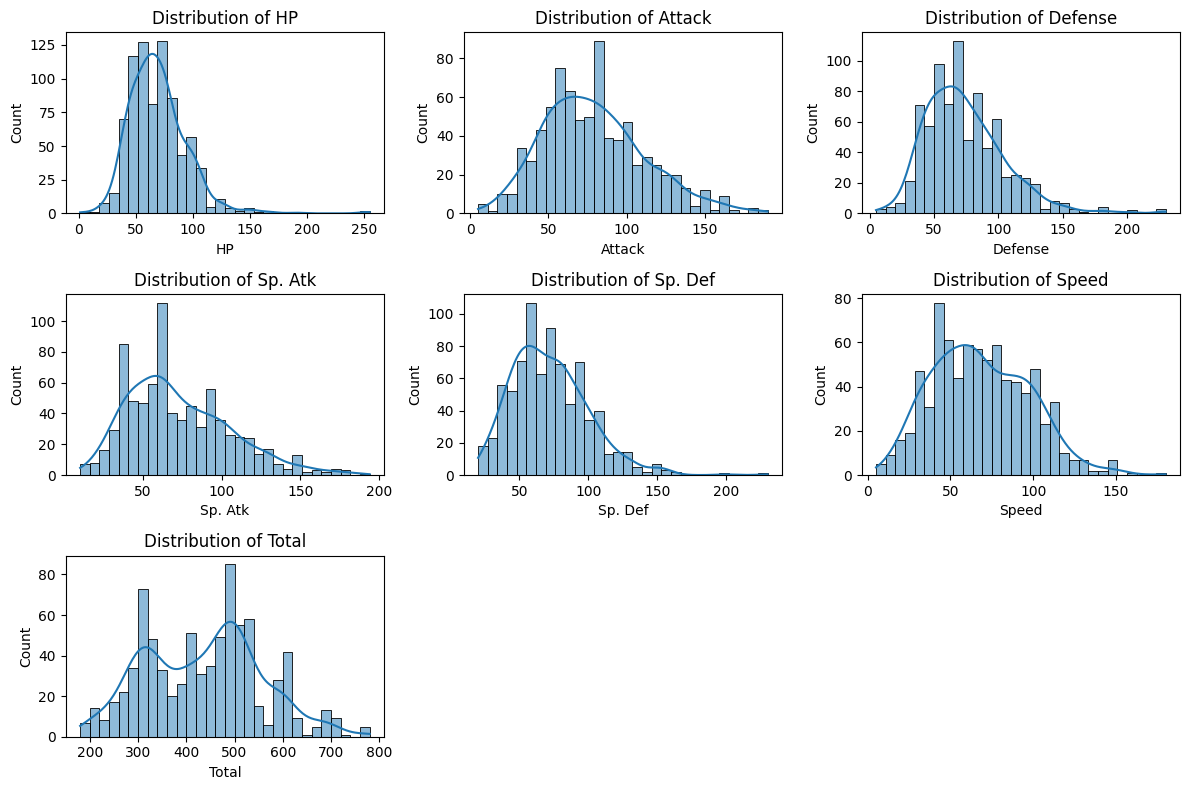

In [28]:
# Your code here . .
stats = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed", "Total"]

plt.figure(figsize=(12, 8))
for i, col in enumerate(stats, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

Observation: Based on the charts so far, only couple of pokemons have extremely high stats and most pokemons have relatively moderate stats. Stats are also peking multiple times. This can be due to different versions of the pokemons, for example, there might be regular pokemons, fully evolved pokemons and legendary pokemons. Probably the most interesting take away from these charts is that speed is the most relatevely evenly spread statistics among Pokemons.



## Q5: Which Pokemon have the Highest and Lowest Total Stats?

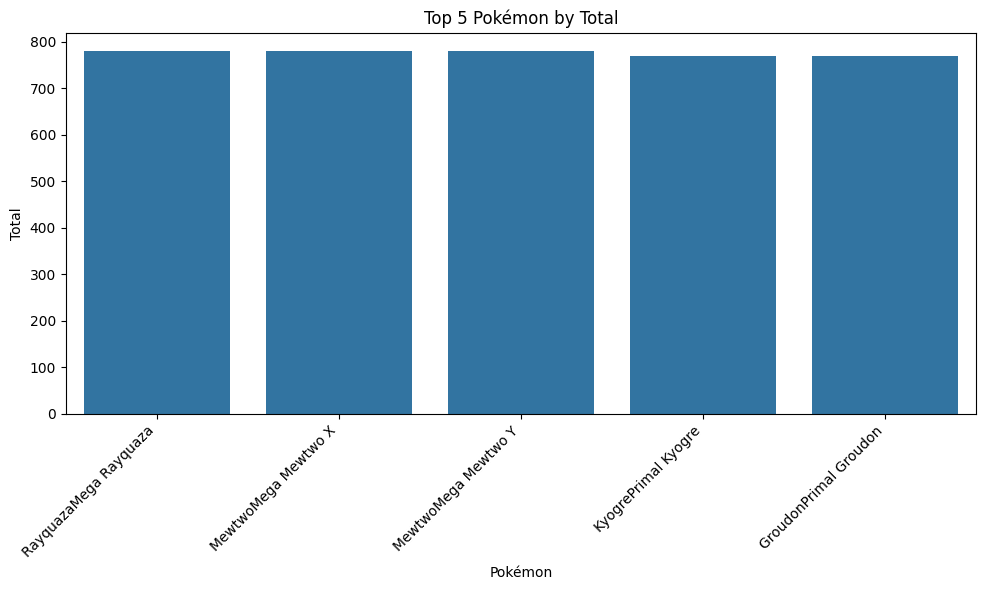

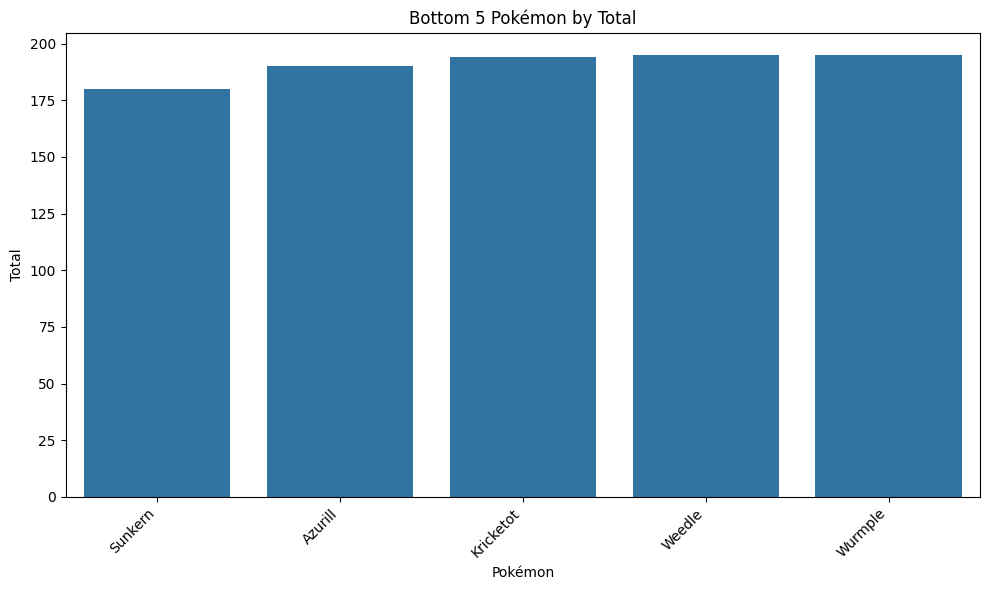

In [32]:
# Your code here . .
top5 = df.sort_values("Total", ascending=False)[["Name", "Total", "Type 1", "Type 2", "Legendary"]].head(5)
bottom5 = df.sort_values("Total", ascending=True)[["Name", "Total", "Type 1", "Type 2", "Legendary"]].head(5)

plt.figure(figsize=(10, 6))
sns.barplot(x="Name", y="Total", data=top5, order=top5.sort_values("Total", ascending=False)["Name"])
plt.title("Top 5 Pokémon by Total")
plt.xlabel("Pokémon")
plt.ylabel("Total")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, top5["Total"].max() * 1.05)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x="Name", y="Total", data=bottom5, order=bottom5.sort_values("Total", ascending=True)["Name"])
plt.title("Bottom 5 Pokémon by Total")
plt.xlabel("Pokémon")
plt.ylabel("Total")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, bottom5["Total"].max() * 1.05)
plt.tight_layout()
plt.show()


Observation: The Top 5 Pokemons by Total are all Legendary or in Mega or Primal forms. Their total stats are extremely high varying from 770 - 780 and they are all relatively close to each other in terms of Total. This shows us that Legendary Pokemons and Mega Evolutions dominate in almost all statistics rankings. On the contrary by logic the bottom 5 Pokemons by Total are all non-legendary basic-stage Pokemon. Their stats range from 180-195, which when compared to top 5 are extremely low.

## Q6: How does the number of Pokemon vary across Generations?

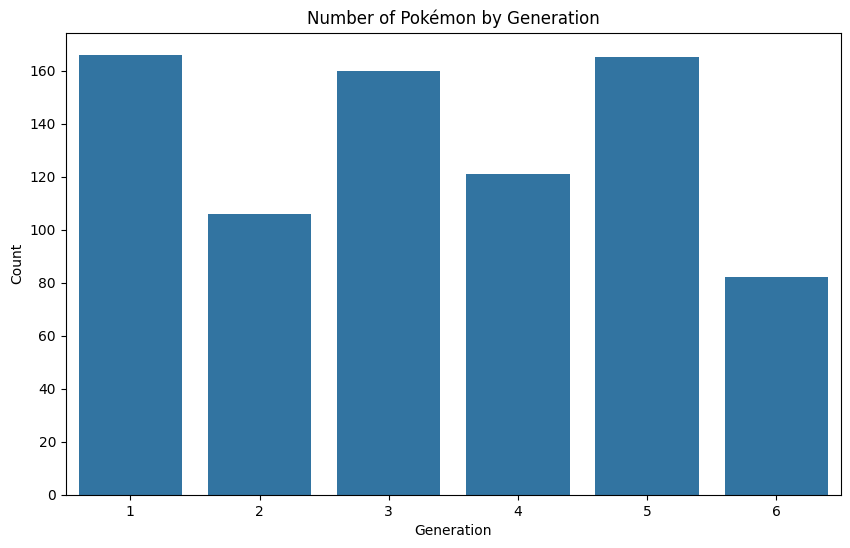

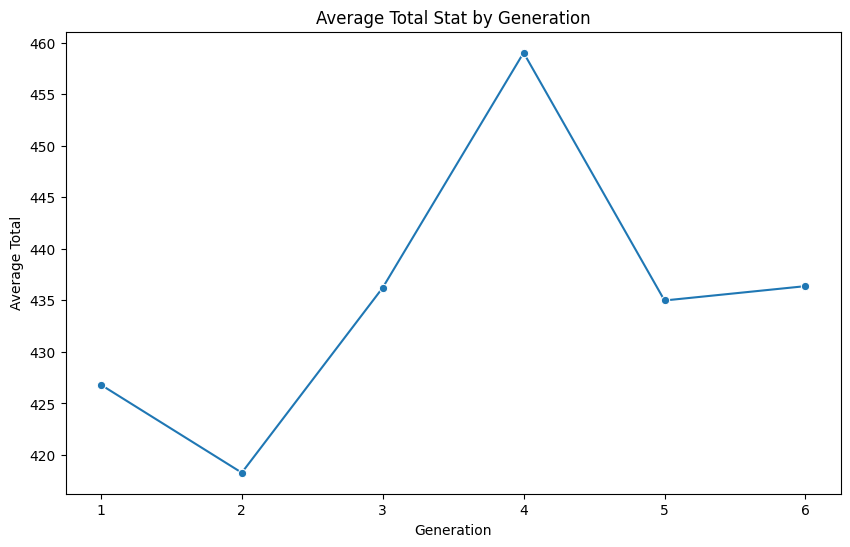

In [33]:
# Your code here . .
gen_counts = df["Generation"].value_counts().sort_index()
plt.figure(figsize=(10, 6))
sns.barplot(x=gen_counts.index, y=gen_counts.values)
plt.title("Number of Pokémon by Generation")
plt.xlabel("Generation")
plt.ylabel("Count")
plt.show()
gen_avg_total = df.groupby("Generation")["Total"].mean()
plt.figure(figsize=(10, 6))
sns.lineplot(x=gen_avg_total.index, y=gen_avg_total.values, marker="o")
plt.title("Average Total Stat by Generation")
plt.xlabel("Generation")
plt.ylabel("Average Total")
plt.show()

Observation: From the charts, we can see that generation 1 and 5 have the highest pokmeon number while generation 6 has the lowest count. From the second chart, we can notice that Generation 4 has the highest average total stat while generation 2 has the lowest average total stat.